In [1]:
!pip install -q kaggle
from google.colab import files
uploaded = files.upload()   # Select kaggle.json when prompted
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('✅ Kaggle credentials configured.')

Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured.


In [2]:
!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data
!unzip -q fracture-multi-region-x-ray-data.zip -d /content/fracture_data
print('✅ Dataset downloaded and extracted.')

Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
100% 481M/481M [00:30<00:00, 16.5MB/s]

✅ Dataset downloaded and extracted.


In [3]:
import os
from pathlib import Path

ROOT = Path('/content/fracture_data')
for p in ROOT.rglob('train'):
    ROOT = p.parent
    break

TRAIN_DIR = ROOT / 'train'
VAL_DIR   = ROOT / 'val'
TEST_DIR  = ROOT / 'test'

for split, d in [('TRAIN', TRAIN_DIR), ('VAL', VAL_DIR), ('TEST', TEST_DIR)]:
    classes = sorted(os.listdir(d))
    print(f'\n{split}: {d}')
    for c in classes:
        n = len(list((d/c).glob('*')))
        print(f'  {c:20s} -> {n} images')


TRAIN: /content/fracture_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
  fractured            -> 4606 images
  not fractured        -> 4640 images

VAL: /content/fracture_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val
  fractured            -> 337 images
  not fractured        -> 492 images

TEST: /content/fracture_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test
  fractured            -> 238 images
  not fractured        -> 268 images


In [4]:
import random, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [5]:
CFG = {
    'img_size'       : 224,
    'batch_size'     : 32,
    'num_workers'    : 2,
    'epochs'         : 20,
    'lr'             : 1e-4,
    'backbone_lr'    : 1e-5,
    'weight_decay'   : 1e-4,
    'patience'       : 5,
    'dropout'        : 0.3,
    'unfreeze_epoch' : 5,
    'save_path'      : '/content/best_model.pth',
    'class_names'    : ['fractured', 'not fractured'],
}
print('Config ready ✅')

Config ready ✅


In [6]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'] + 32, CFG['img_size'] + 32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_tf)

print('Class mapping:', train_ds.class_to_idx)
assert set(train_ds.classes) == set(CFG['class_names']), \
    f'Class mismatch! Found: {train_ds.classes}'
print('✅ Class names verified.')

train_dl = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                      num_workers=CFG['num_workers'], pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                      num_workers=CFG['num_workers'], pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                      num_workers=CFG['num_workers'], pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Class mapping: {'fractured': 0, 'not fractured': 1}
✅ Class names verified.
Train: 9246 | Val: 829 | Test: 506


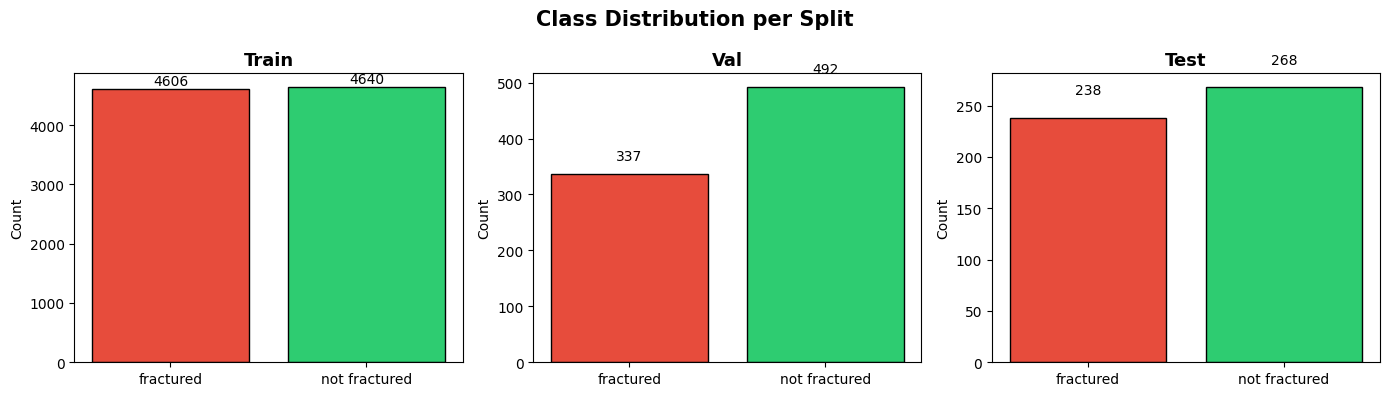

In [7]:
splits = {'Train': train_ds, 'Val': val_ds, 'Test': test_ds}
rows = []
for split_name, ds in splits.items():
    for cls_idx, cls_name in enumerate(ds.classes):
        count = sum(1 for _, label in ds.samples if label == cls_idx)
        rows.append({'Split': split_name, 'Class': cls_name, 'Count': count})
df_dist = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (split_name, group) in zip(axes, df_dist.groupby('Split', sort=False)):
    ax.bar(group['Class'], group['Count'], color=['#E74C3C', '#2ECC71'], edgecolor='black')
    ax.set_title(split_name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
plt.suptitle('Class Distribution per Split', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

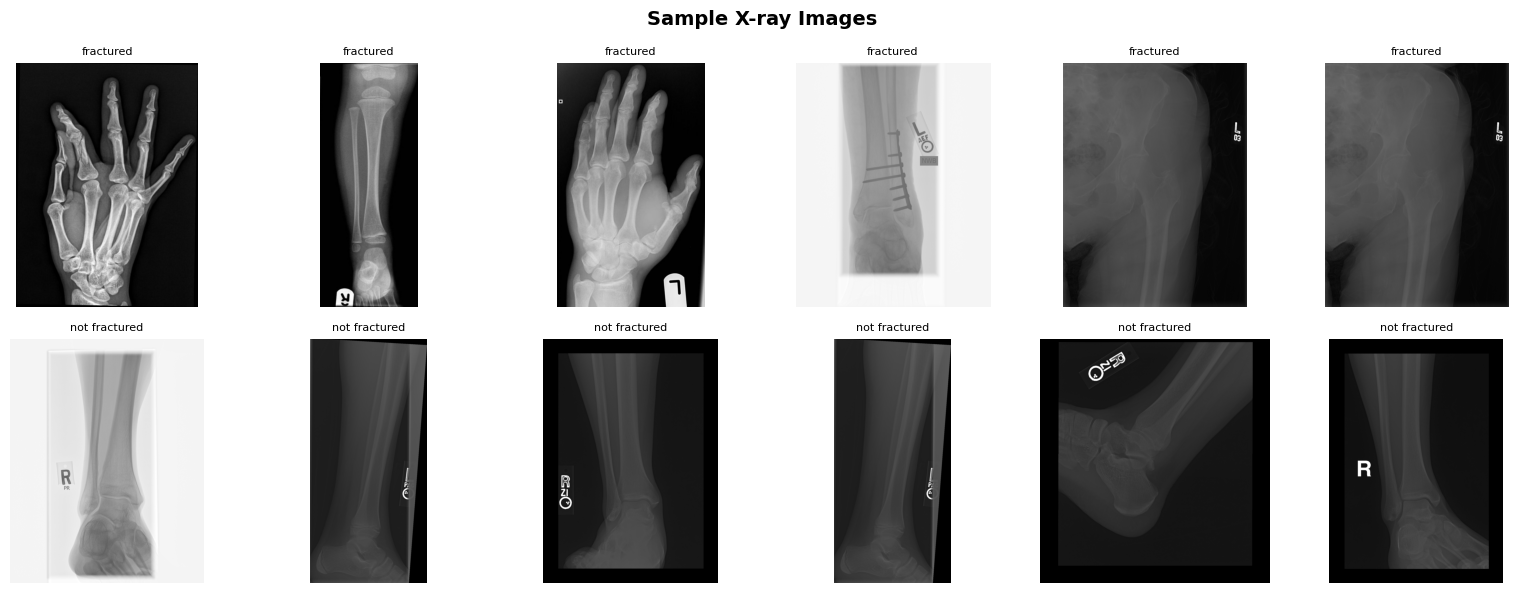

In [8]:
def denormalize(tensor, mean=MEAN, std=STD):
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return (tensor * s + m).clamp(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for row, cls_name in enumerate(train_ds.classes):
    cls_idx = train_ds.class_to_idx[cls_name]
    paths = [p for p, l in train_ds.samples if l == cls_idx][:6]
    for col, p in enumerate(paths):
        img = Image.open(p).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls_name, fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('Sample X-ray Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:


def build_model(dropout=CFG['dropout']):
    model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=False),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=dropout / 2, inplace=False),
        nn.Linear(256, 1),
    )
    return model

model = build_model().to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total:,}')
print(f'Trainable params: {trainable:,} (head only at start)')

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 195MB/s]


Total params: 20,505,681
Trainable params: 328,193 (head only at start)


In [10]:
criterion = nn.BCEWithLogitsLoss(reduction='mean')

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay']
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print('Loss, optimizer, scheduler ready ✅')

Loss, optimizer, scheduler ready ✅


In [26]:
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    """One full epoch. Returns (avg_loss, accuracy)."""
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()

    running_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)  # (B, 1)

            logits = model(imgs)                # (B, 1)
            loss   = criterion(logits, labels)  # mean BCE

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds         = (torch.sigmoid(logits) >= 0.5).float()
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)
            running_loss += loss.item() * labels.size(0)

    return running_loss / total, correct / total


def unfreeze_backbone(model, optimizer):
    """Unfreeze backbone and add its parameters to the optimizer exactly once."""
    existing_ids = {id(p) for group in optimizer.param_groups for p in group['params']}
    new_params = []
    for param in model.features.parameters():
        param.requires_grad = True
        if id(param) not in existing_ids:
            new_params.append(param)
    if new_params:
        optimizer.add_param_group({
            'params': new_params,
            'lr': CFG['backbone_lr'],
            'weight_decay': CFG['weight_decay'],
        })
    print(f'Backbone unfrozen - {len(new_params)} params added to optimizer.')


history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')
best_val_acc   = 0.0
patience_counter = 0

header = '{:>6} | {:>10} | {:>9} | {:>8} | {:>7} | LR'
print(header.format('Epoch', 'Train Loss', 'Train Acc', 'Val Loss', 'Val Acc'))
print('-' * 70)

for epoch in range(1, CFG['epochs'] + 1):

    if epoch == CFG['unfreeze_epoch']:
        unfreeze_backbone(model, optimizer)

    train_loss, train_acc = run_epoch(model, train_dl, criterion, optimizer, 'train')
    val_loss,   val_acc   = run_epoch(model, val_dl,   criterion, phase='val')
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    lr_now = optimizer.param_groups[0]['lr']
    row = '{:>6} | {:>10.4f} | {:>8.2%} | {:>8.4f} | {:>6.2%} | {:.2e}'
    print(row.format(epoch, train_loss, train_acc, val_loss, val_acc, lr_now))

    if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
        best_val_acc   = val_acc
        best_val_loss  = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CFG['save_path'])
        print('   Saved best  val_acc={:.2%}  val_loss={:.4f}'.format(val_acc, val_loss))
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print('Early stopping at epoch {}'.format(epoch))
            break

print('\nTraining complete.')
print('Best val_acc: {:.2%}  |  Best val_loss: {:.4f}'.format(best_val_acc, best_val_loss))

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | LR
----------------------------------------------------------------------
     1 |     0.6209 |   68.25% |   0.5532 | 77.45% | 1.00e-04
   Saved best  val_acc=77.45%  val_loss=0.5532
     2 |     0.5248 |   75.39% |   0.5004 | 76.97% | 1.00e-04
     3 |     0.4959 |   76.29% |   0.4972 | 75.15% | 1.00e-04
     4 |     0.4837 |   77.15% |   0.4657 | 78.06% | 1.00e-04
   Saved best  val_acc=78.06%  val_loss=0.4657
Backbone unfrozen - 450 params added to optimizer.
     5 |     0.3477 |   84.72% |   0.2556 | 89.58% | 1.00e-04
   Saved best  val_acc=89.58%  val_loss=0.2556
     6 |     0.1557 |   94.25% |   0.1523 | 95.03% | 1.00e-04
   Saved best  val_acc=95.03%  val_loss=0.1523
     7 |     0.0830 |   97.22% |   0.1181 | 96.00% | 1.00e-04
   Saved best  val_acc=96.00%  val_loss=0.1181
     8 |     0.0567 |   98.12% |   0.0859 | 97.21% | 1.00e-04
   Saved best  val_acc=97.21%  val_loss=0.0859
     9 |     0.0407 |   98.68% |   0.0747 

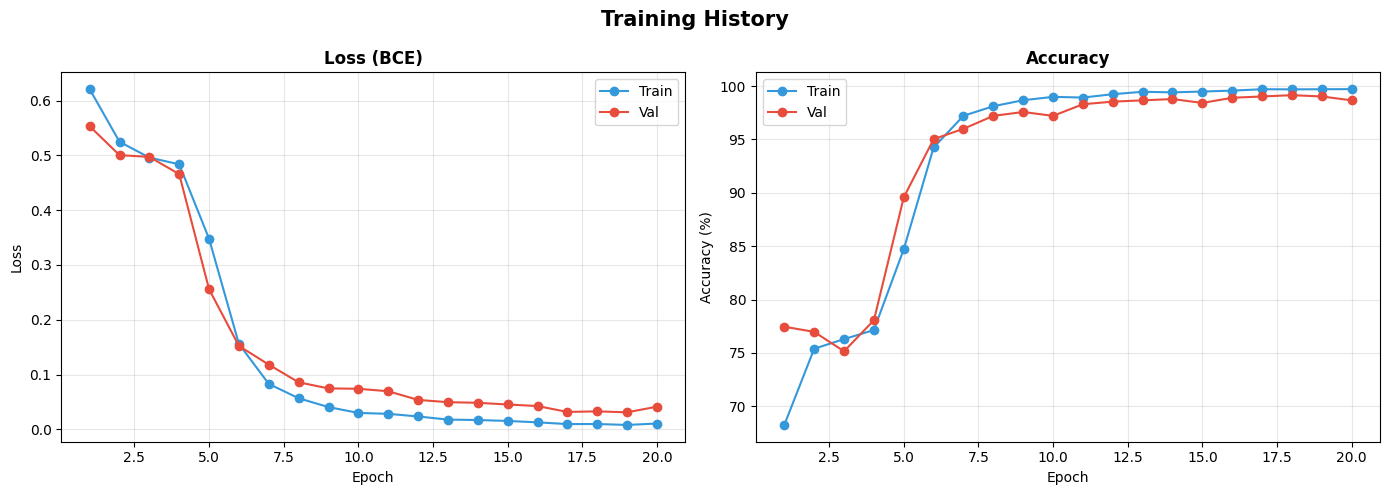

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o', color='#3498DB')
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='o', color='#E74C3C')
ax1.set_title('Loss (BCE)', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train', marker='o', color='#3498DB')
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   label='Val',   marker='o', color='#E74C3C')
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
BEST_THRESHOLD = 0.20
model.load_state_dict(torch.load(CFG['save_path'], map_location=DEVICE))
model.eval()

all_labels, all_probs, all_preds = [], [], []

with torch.no_grad():
    for imgs, labels in test_dl:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs).squeeze(1).cpu()
        probs  = torch.sigmoid(logits).numpy()
        preds = (probs >= BEST_THRESHOLD).astype(int)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        all_preds.extend(preds)

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)

print('Classification Report')
print('=' * 55)
print(classification_report(all_labels, all_preds, target_names=train_ds.classes))
auc = roc_auc_score(all_labels, all_probs)
print('ROC-AUC: {:.4f}'.format(auc))

Classification Report
               precision    recall  f1-score   support

    fractured       1.00      0.97      0.98       238
not fractured       0.97      1.00      0.99       268

     accuracy                           0.98       506
    macro avg       0.99      0.98      0.98       506
 weighted avg       0.98      0.98      0.98       506

ROC-AUC: 0.9983


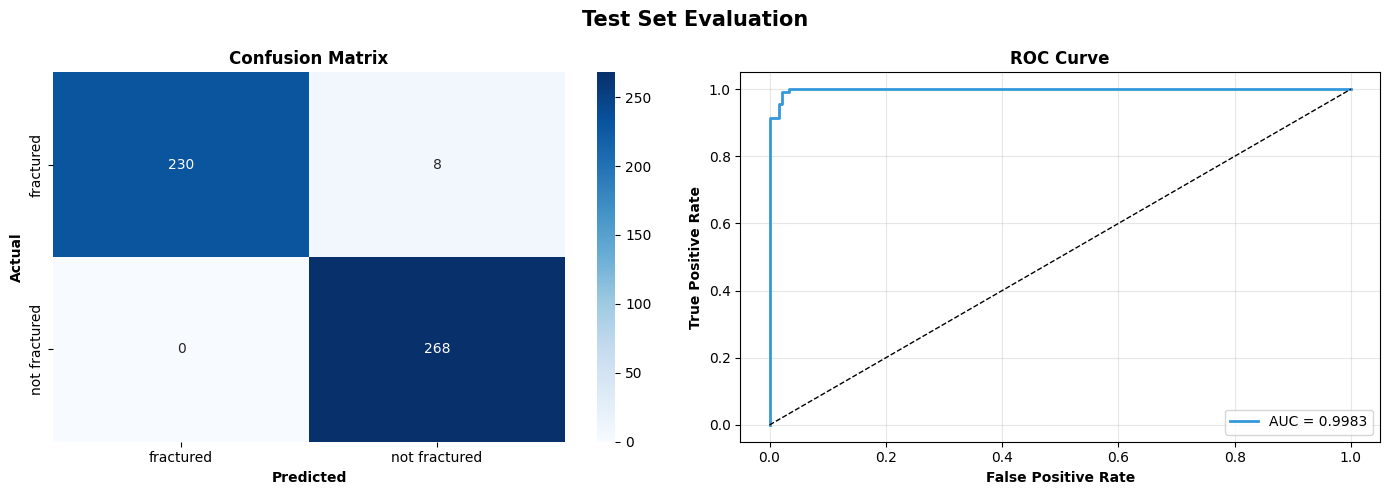

In [38]:
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes, ax=axes[0])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='#3498DB', lw=2, label='AUC = {:.4f}'.format(auc))
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Test Set Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 106.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


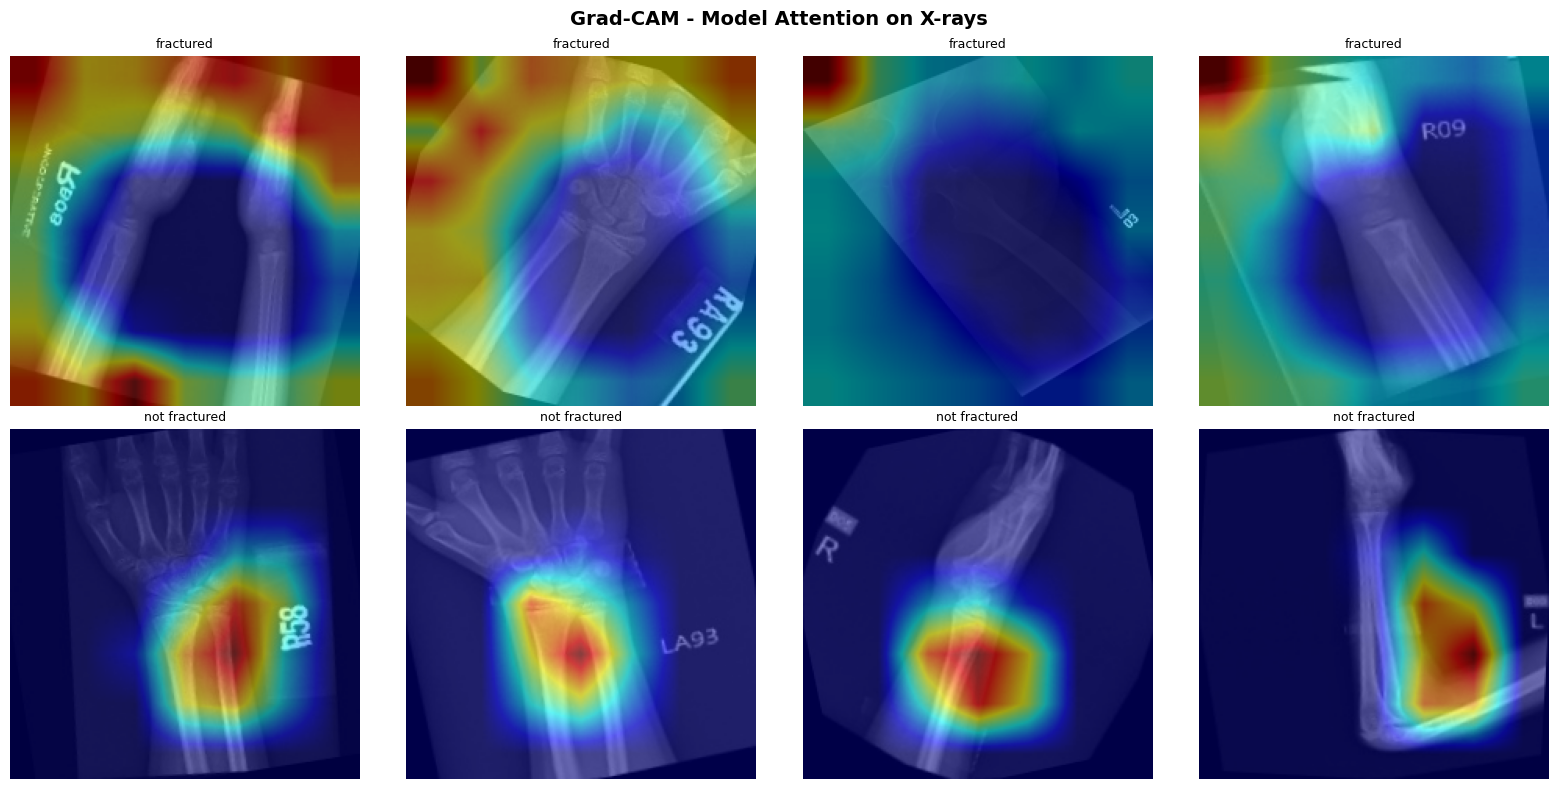

In [39]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import random

target_layers = [model.features[-1][0]]
cam = GradCAM(model=model, target_layers=target_layers)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, cls_name in enumerate(test_ds.classes):
    cls_idx   = test_ds.class_to_idx[cls_name]
    all_paths = [p for p, l in test_ds.samples if l == cls_idx]
    paths     = random.sample(all_paths, 4)
    for col, img_path in enumerate(paths):
        pil_img = Image.open(img_path).convert('RGB').resize((CFG['img_size'], CFG['img_size']))
        rgb_img = np.array(pil_img) / 255.0
        input_tensor  = val_tf(pil_img).unsqueeze(0).to(DEVICE)
        grayscale_cam = cam(input_tensor=input_tensor)[0]
        visualization = show_cam_on_image(rgb_img.astype(np.float32), grayscale_cam, use_rgb=True)
        axes[row, col].imshow(visualization)
        axes[row, col].set_title(cls_name, fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Grad-CAM - Model Attention on X-rays', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_to_idx': train_ds.class_to_idx,
    'cfg': CFG,
    'best_val_loss': best_val_loss,
    'best_val_acc': best_val_acc,
    'threshold': BEST_THRESHOLD,
    'history': history,
}, '/content/fracture_model_full.pth')
print('Model saved ✅')

from google.colab import files
files.download('/content/fracture_model_full.pth')
files.download('/content/training_curves.png')
files.download('/content/evaluation.png')
files.download('/content/gradcam.png')

Model saved ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

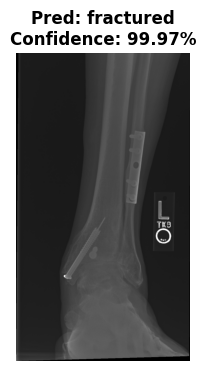

('fractured', 0.9996952167421114)

In [48]:
def predict_image(image_path, model, transform, class_names, device):
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logit = model(tensor).squeeze().item()
        prob  = torch.sigmoid(torch.tensor(logit)).item()
    idx        = int(prob >= 0.5)
    pred_class = class_names[idx]
    confidence = prob if idx == 1 else 1 - prob
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title('Pred: {}\nConfidence: {:.2%}'.format(pred_class, confidence), fontweight='bold')
    plt.axis('off')
    plt.show()
    return pred_class, confidence


# Example - replace with your image path:
class_names_ordered = [k for k, v in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]
predict_image('/content/0089.png', model, val_tf, class_names_ordered, DEVICE)

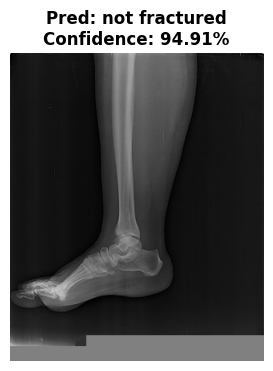

('not fractured', 0.9491309523582458)

In [47]:
def predict_image(image_path, model, transform, class_names, device):
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logit = model(tensor).squeeze().item()
        prob  = torch.sigmoid(torch.tensor(logit)).item()
    idx        = int(prob >= 0.5)
    pred_class = class_names[idx]
    confidence = prob if idx == 1 else 1 - prob
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title('Pred: {}\nConfidence: {:.2%}'.format(pred_class, confidence), fontweight='bold')
    plt.axis('off')
    plt.show()
    return pred_class, confidence


# Example - replace with your image path:
class_names_ordered = [k for k, v in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]
predict_image('/content/IMG0004134.jpg', model, val_tf, class_names_ordered, DEVICE)